
---

## **Part 1 — Exploring Different Modalities / Representations of Network Traffic**

Synthetic network traffic generation is useful for many applications such as dataset augmentation, network testing, and resource management. Many existing generation methods treat traffic generation as either a time-series prediction task or an autoregressive modeling task. In these approaches, models are trained directly on structured representations of packets—one common example is **nPrint**, a tabular format that encodes packet header fields from PCAP traces into machine-learning-friendly numerical vectors.

In an **nPrint**, each row represents one packet in a trace. The entire nPrint file (a large CSV) represents all packets of that trace in sequential order. Header fields are encoded using one-hot–like binary indicators (e.g., `1`, `0`, or `01`), making them easy to feed into ML models.

However, general-purpose ML models—even advanced time-series architectures and transformers—often struggle to capture the *complex dependencies* present in real network traffic:

* **Local dependencies**: relationships among columns within a single row (i.e., dependencies among header fields of a single packet).
* **Global dependencies**: relationships across rows (i.e., the evolution of packets within the same flow).
  For example: if the first packet of a flow uses TCP, the second packet in that same flow should also be TCP; sequence numbers, flags, and flow identifiers evolve in structured ways over time.

While sequential ML models struggle with these multi-scale dependencies, **vision models** (e.g., diffusion models) excel at capturing both local and global structure when data is presented spatially—like an image. By converting nPrint traces into 2D PNG images, we can take advantage of the strong representational capabilities of image models and generate synthetic traffic using visual generative approaches.

---

### **Your Task for Part 1**

In this part of the assignment, you will:

1. **Inspect the raw nPrint files** (found in the `real_nprints` directory).
2. **Understand how each CSV row and column corresponds to packet-level metadata.**
3. **Follow the provided conversion pipeline** that transforms these nPrint CSVs into PNG image representations suitable for use with diffusion models and other visual architectures.
4. **Take an already generated set of image-representation of images and convert them back into nprint representation for downstream task utilization**

This will help you understand why converting network traces to images can unlock generative modeling capabilities that traditional ML approaches struggle with.

Q1:
First, download and unzip the data you will need from (https://drive.google.com/file/d/1hY6nNXEYOwl1l-O_nCknO9xezcHr6ZXi/view?usp=sharing)
In your own words, describe how an nPrint CSV encodes a network trace.
Why might a 2D image representation capture structural relationships that a row-by-row CSV cannot?

An nPrint csv encodes a network trace by inputting a packet into a row, with every column being a single bit of a named header field. The columns are fixed in advance, so every row is fixed-width and all the rows align. Because 0 and 1 are taken by real bit values, absent bits are marked -1.

A two-dimensional representation captures structural relationships that a row-by-row CSV cannot, because a CSV presents each packet as an independent sample without comparison. Stacking packets into a grid makes the vertical axis meaningful: each column becomes the same header field observed across consecutive packets. Behavior that spans multiple packets, like a TTL holding constant, sequence numbers incrementing, the shape of a handshake, becomes a visible pattern rather than a relationship the model has to infer from unrelated rows.

Q2. Design a method for converting nPrint representations of traces (in the folder real_nprints) into image representations.
Your image representation should use only the first 1024 packets from each trace to avoid producing images that are too large.
Save the images into a folder called './nd_data/student_converted_images'

In [32]:
# Setup. Imports and the constants used throughout the conversion.
# MAX_PACKETS fixes every image at 1024 rows. PAD_VALUE is the value
# used to pad traces shorter than that — -1, which is nPrint's own
# symbol for a bit that isn't present. LEVELS defines the pixel encoding:
# absent bits become black (0), zero bits mid-grey (128), and one bits white (255).

import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

MAX_PACKETS = 1024
PAD_VALUE   = -1
LEVELS      = {-1: 0, 0: 128, 1: 255}   # absent, off, on

In [33]:
# Conversion functions. load_nprint reads a .nprint file into a numpy array,
# dropping the leading packet-counter column and checking that only -1, 0,
# and 1 appear. fit_to_height forces the result to exactly 1024 rows by truncating
# longer traces or padding shorter ones with -1 rows, so every image comes out the
# same size. to_image maps the three values to grey levels — -1→0, 0→128, 1→255 —
# producing an 8-bit array ready to save as a PNG.


def load_nprint(path):
    """Read one .nprint file; drop the packet-counter column."""
    arr = pd.read_csv(path, index_col=0).to_numpy(dtype=np.int8)
    bad = np.setdiff1d(np.unique(arr), np.array([-1, 0, 1], dtype=np.int8))
    if bad.size:
        raise ValueError(f"{path.name}: unexpected values {bad.tolist()}")
    return arr

def fit_to_height(arr, height=MAX_PACKETS):
    """Truncate to the first `height` packets, or pad with -1 rows."""
    if arr.shape[0] >= height:
        return arr[:height]
    pad = np.full((height - arr.shape[0], arr.shape[1]), PAD_VALUE, dtype=arr.dtype)
    return np.vstack([arr, pad])

def to_image(arr):
    """Ternary bit matrix -> 8-bit grayscale."""
    out = np.empty(arr.shape, dtype=np.uint8)
    out[arr == -1] = LEVELS[-1]
    out[arr ==  0] = LEVELS[0]
    out[arr ==  1] = LEVELS[1]
    return out

In [34]:
# Run the conversion. Finds every .nprint file in real_nprints,
# passes each through the three functions above, and writes the result to
# student_converted_images as a PNG named after the source file. Progress
# prints every 20 traces.

SRC = Path.home() / "Downloads/nd_data/real_nprints"
DST = Path.home() / "Downloads/nd_data/student_converted_images"
DST.mkdir(parents=True, exist_ok=True)

files = sorted(SRC.glob("*.nprint"))
print(f"{len(files)} traces found")

for i, path in enumerate(files, 1):
    img = to_image(fit_to_height(load_nprint(path)))
    Image.fromarray(img, mode="L").save(DST / f"{path.stem}.png", optimize=True)
    if i % 20 == 0:
        print(f"  {i}/{len(files)}")

print("done")

200 traces found
  20/200
  40/200
  60/200
  80/200
  100/200
  120/200
  140/200
  160/200
  180/200
  200/200
done


In [35]:
# Verification. Confirms the output is what it should be: 200 images,
# all 1088×1024 grayscale, 20 per class. The final check decodes one PNG
# back into nPrint values and compares it to the source trace — if it matches,
# the encoding lost nothing.

from collections import Counter

pngs = sorted(DST.glob("*.png"))
sizes = {Image.open(p).size for p in pngs}
modes = {Image.open(p).mode for p in pngs}

print(f"images      : {len(pngs)}")
print(f"dimensions  : {sizes}")
print(f"modes       : {modes}")
print(f"per class   : {dict(Counter(p.stem.split('_')[0] for p in pngs))}")

# encoding is injective, so the original matrix is recoverable
sample = pngs[0]
back = np.select(
    [np.array(Image.open(sample)) == v for v in LEVELS.values()],
    list(LEVELS.keys()),
).astype(np.int8)
orig = fit_to_height(load_nprint(SRC / f"{sample.stem}.nprint"))
print(f"round-trip  : {np.array_equal(orig, back)}")


images      : 200
dimensions  : {(1088, 1024)}
modes       : {'L'}
per class   : {'amazon': 20, 'facebook': 20, 'instagram': 20, 'meet': 20, 'netflix': 20, 'teams': 20, 'twitch': 20, 'twitter': 20, 'youtube': 20, 'zoom': 20}
round-trip  : True


In [36]:
# Guard. Fails immediately with a clear message if the output folder is empty,
# rather than letting a later line crash with an unhelpful IndexError.
pngs = sorted(DST.glob("*.png"))
assert pngs, f"no PNGs in {DST} — did the conversion cell run?"

In [39]:
# The following is a pre-defined script used in NetDiffusion that will convert all of the provided real nprints into image representations. Run this code and observe the output
!python ~/Desktop/ml-systems/docs/assignments/netdiffusion-main/scripts/nprint_to_png.py -i ~/Downloads/nd_data/real_nprints -o ~/Downloads/nd_data/real_traffic_images

Processing teams_1024_10.nprint
/Users/angelina/Desktop/ml-systems/docs/assignments/netdiffusion-main/scripts/nprint_to_png.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  np_df = np.array(df.applymap(np.array).to_numpy().tolist())
Processing twitch_1024_7.nprint
/Users/angelina/Desktop/ml-systems/docs/assignments/netdiffusion-main/scripts/nprint_to_png.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  np_df = np.array(df.applymap(np.array).to_numpy().tolist())
Processing netflix_1024_15.nprint
/Users/angelina/Desktop/ml-systems/docs/assignments/netdiffusion-main/scripts/nprint_to_png.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  np_df = np.array(df.applymap(np.array).to_numpy().tolist())
Processing twitter_1024_17.nprint
/Users/angelina/Desktop/ml-systems/docs/assignments/netdiffusion-main/scripts/nprint_to_png.py:26: FutureWarning: DataFrame.applymap has be

Q3: Now that you have seen how NetDiffusion converts nPrints into images, compare their method with the approach you designed in Q2. What are the advantages and disadvantages of each, especially in terms of what might help or hinder a vision model’s ability to learn?

## Q2 method: 
Each of the 200 files is a spreadsheet of a network trace, resulting in 1024 rows representing 1024 packets. Every cell in the row is -1 (black), 0 (grey), or 1 (white). Each cell is a pixel and in the same position as it in in the spreadsheet. 

Advantages:

- One channel, no redundancy — the three states fit in a single number
- 4× smaller files (32 KB vs 71 KB), so more images fit per training batch
- Packet-counter column dropped, so every pixel is real trace data
- Lossless and verified — images decode back to the original .nprint values exactly

Disadvantages:

- 0 / 128 / 255 implies an ordering (absent < off < on) that doesn't exist; the three states are unordered categories
- Can't feed a pretrained RGB backbone without duplicating the channel or modifying the input layer
- Three grey levels sit on one axis, so they're less separable under noise than three primaries





## NetDiffusion's method:
The same idea; every cell is either -1 (blue), 0 (green), or 1 (red). Traces shorter than 1024 packets get padded with blue rows, the same as my -1 rows. Instead of grayscale, NetDiffusion uses RGBA (Alpha being opacity, defining the magnitude)

Advantages

- Red / green / blue are orthogonal, so no false ordering is imposed on the three categories
- RGB output works directly with pretrained vision models — valuable with only 20 traces per class
- Maximum color separation makes decoding robust to noise
- Drops source and destination IP columns, preventing a model from memorizing hosts

Disadvantages

- Alpha is constant on all real data — a quarter of the tensor carries no information
- Keeps the packet-counter column: identical across classes, but visually salient, so a convolutional model wastes capacity on it
- 4× the storage and ~10× slower to generate
- No truncation — a trace longer than 1024 packets raises an error instead of being trimmed



---

## **Part 2 — Converting Generated Images Back Into Usable Format**

In the first part of the assignment, you explored how network traces in nPrint format can be transformed into image representations suitable for vision-based generative models. In Part 2, we focus on the reverse process: taking synthetic images produced by these models and converting them back into structured network representations.

This step is crucial because real-world applications do not operate on images—they require valid, interpretable packet traces that can be analyzed, replayed, or integrated into downstream tools.

---

### **Your Task for Part 2**

In this part of the assignment, you will:

1. **Convert generated images back into the original nPrint representation.**
   You will follow a scripted pipeline that translates pixel intensities and color channels back into binary header fields, reconstructing the packet-level structure of the trace.

2. **Apply essential post-processing techniques to correct errors introduced by diffusion models.**
   Generated images are rarely perfect—vision models may introduce color drift, pixel misalignment, noise, or structural artifacts.
   You will observe how heuristic correction, formatting enforcement, and reconstruction steps ensure that the converted nPrints become:

   * syntactically valid,
   * structurally consistent,
   * and replayable.

Across this section, your goal is to understand **why the reverse transformation is fragile**, which types of artifacts break reversibility, and how post-processing logic helps repair or compensate for generative errors.

For simplicity of this assignment, we have trainined and generated the images for you. If you have sufficient GPU access and want to try fine-tuning the model and generating the images yourself, feel free to take a look at the public repo (https://github.com/noise-lab/NetDiffusion).


Q4: We have taken the images converted by NetDiffusion and trained a LoRA-fine-tuned Stable Diffusion model (with ControlNet) to generate synthetic traffic images for you. These generated samples are stored in generated_traffic_images/.
Compare these generated images visually with the real images you saw earlier in real_traffic_images/.

Do you notice anything different between the real and generated traffic images? What immediately stands out as potentially problematic if we attempt to convert these generated images back into nPrint format? (Descriptive Only)


The real images are discrete, meaning they have pure red, green, and blue. The generated images contain 300,000 distinct colors with no single pure primary. The blue, for example, turned into a desaturated purple. They are also visibly smoothed, with soft vertical streaking replacing the sharp pixel-to-pixel transitions of a real bit matrix.

It would be difficult to convert these images back into nPrint format because there is no matching legend anymore. The generated image doesn't have pixels that are exactly red, green, or blue so it cannot decode for 1, 0, or -1. 

Q5: If you were to design a method to convert generated images back into nPrints, how would you do it? Explain your approach and describe how your method addresses the concerns you raised in Q4. (Descriptive only)

First, I would fix the shape. The generated images are 1088 columns wide but the converter produces 1089. The missing column is the counter column, which carries no trace information, so I can regenerate it from scratch rather than having to recover anything.

Second, I would classify each pixel as red, green, or blue by which pure color its RGB value sits closest to — but I would also record how far away it was, as a confidence score, rather than discarding that distance.

Third, I would use those scores to repair low-confidence pixels. Real nPrint images have large contiguous regions where a whole field is absent, so a pixel that decoded ambiguously but sits inside a block of confident -1s is almost certainly -1 too, and the smoothing just blurred it. I would take a confidence-weighted majority vote within each field's block, never across field boundaries, since neighbors in different fields can legitimately differ.

Fourth, I would enforce nPrint's hard structural rules per packet. A packet can be TCP or UDP but not both. A protocol that isn't present has all its bits set to -1, and option fields are -1 past whatever header length the packet declares. These are rules rather than guesses, so wherever a decoded pixel disagrees, the rule wins. This rebuilds a large fraction of the trace exactly, without relying on pixels at all.

Fifth, because some fields shouldn't be decoded at all — they're computable — I would recalculate every deterministic field: version numbers, header lengths, total lengths, and checksums all follow from the rest of the packet, so computing them is simply more reliable than reading them off noisy pixels.

Lastly, I would check the results with a real packet parser and throw away anything that won't parse or was decoded with low confidence throughout. A smaller set of trustworthy synthetic packets is more useful than a larger set containing subtly broken ones.

These steps address Q4's problems by not relying on the pixels alone. Nearest-color classification is the weakest part of the pipeline — the drift is severe enough that in the images I checked, the IPv4 version field decoded to 0 instead of 4 in all 1024 packets, even though that field is constant by definition. The structural rules and field recalculation are what compensate: they rebuild large portions of each packet from constraints rather than from color, so the damage from drift and smoothing is confined to the fields that genuinely can't be derived any other way. The parser check then catches whatever survives that but still isn't valid.

Below are a set of pre-written scripts that perform the necessary post-generation augmentation and processing on the synthetic images you obtained from the diffusion model. These scripts handle tasks such as color normalization/augmentation and conversion from generated images back into nPrint format.
(The PCAP step is optional — you may run it if you are interested in observing or replaying the reconstructed traffic.)

In [41]:
# Step 1: Color Augmentation
!python ~/Desktop/ml-systems/docs/assignments/netdiffusion-main/scripts/color_processor.py \
  --input_dir="$HOME/Downloads/nd_data/generated_traffic_images" \
  --output_dir="$HOME/Downloads/nd_data/color_corrected_generated_traffic_images"

Processed 100 images.


In [42]:
# Step 2: Convert the color-corrected images back into nprint format
!python ~/Desktop/ml-systems/docs/assignments/netdiffusion-main/scripts/image_to_nprint.py \
  --org_nprint="$HOME/Downloads/nd_data/real_nprints/amazon_1024.nprint" \
  --input_dir="$HOME/Downloads/nd_data/color_corrected_generated_traffic_images" \
  --output_dir="$HOME/Downloads/nd_data/generated_nprint"

Processing /Users/angelina/Downloads/nd_data/color_corrected_generated_traffic_images/teams_5.png with size 1088 x 1024
Saved /Users/angelina/Downloads/nd_data/generated_nprint/teams_5.nprint
Processing /Users/angelina/Downloads/nd_data/color_corrected_generated_traffic_images/twitch_3.png with size 1088 x 1024
Saved /Users/angelina/Downloads/nd_data/generated_nprint/twitch_3.nprint
Processing /Users/angelina/Downloads/nd_data/color_corrected_generated_traffic_images/zoom_7.png with size 1088 x 1024
Saved /Users/angelina/Downloads/nd_data/generated_nprint/zoom_7.nprint
Processing /Users/angelina/Downloads/nd_data/color_corrected_generated_traffic_images/zoom_6.png with size 1088 x 1024
Saved /Users/angelina/Downloads/nd_data/generated_nprint/zoom_6.nprint
Processing /Users/angelina/Downloads/nd_data/color_corrected_generated_traffic_images/twitch_2.png with size 1088 x 1024
Saved /Users/angelina/Downloads/nd_data/generated_nprint/twitch_2.nprint
Processing /Users/angelina/Downloads/nd_

Q6: You may now read through the provided scripts in color_processor.py (color augmentation / normalization) and image_to_nprint.py (image → nPrint reconstruction).
How do the post-processing methods implemented in these scripts compare to the approach you proposed in Q5?
Describe the pros and cons of both methods and highlight any differences in design philosophy, robustness, or assumptions.

Comparing the two methods, both start the same way. NetDiffusion regenerates the counter column by writing the CSV with index=True, which is what I proposed — the column holds no trace information, so it is recreated rather than recovered. Both then snap every pixel to one of the three primaries before decoding, and both recalculate fields that can be derived rather than trusting the pixels.

The differences are in how carefully each handles uncertainty. I proposed classifying by nearest RGB distance and keeping that distance as a confidence score; color_processor.py instead picks whichever channel is largest and records nothing. The two disagree on desaturated pixels, where argmax will confidently choose a primary on a margin of a few units. Because the confidence is discarded at that step — before the decoder ever runs — NetDiffusion has no equivalent to my majority-voting repair: by then every pixel looks equally certain. protocol_determination also counts non-negative cells across the whole trace and picks one protocol for the entire file, where I proposed deciding per packet. And NetDiffusion never rejects anything, while I proposed discarding samples that decode poorly.

Each approach has a cost. NetDiffusion's simplicity means nothing to tune and output every time, but it cannot tell a well-generated image from a badly-generated one, since both produce a parseable pcap. Mine preserves more information and would catch bad samples, but it adds a window size and threshold that need tuning, shrinks the dataset through rejection — a real loss when generating data is the whole point — and has not actually been run. Their assumptions are also stronger: one protocol per trace is more noise-tolerant than a per-packet decision, but cannot represent real traffic mixing TCP and UDP. My assumption, that a pixel's neighbours within the same field are informative about it, is weaker but unverified.


---

# **Part 3 — Using Real and Synthetic nPrints for Application Classification**

In the previous parts, you learned how network traces can be converted between nPrint and image representations, generated using diffusion models, and reconstructed back into nPrint format.
Now, you will evaluate how useful these generated nPrints are for downstream **machine learning tasks**.

Each nPrint file—whether real or generated—is labeled with the **application** that produced the traffic (e.g., `amazon_1.nprint` means this sample came from Amazon traffic).
In this section, you will treat each **entire nPrint file as a single sample** and build a simple ML pipeline to classify application labels.

To simplify the task, you will restrict your model to use **only the first 3 packets** (3 rows) from each nPrint.
This mimics “early packet classification,” where only the beginning of a flow is available.

---


Q7:

You now have access to both `real_nprints/` and `generated_nprint/`.
Notice that in both directories, files are labeled using the application associated with that nPrint (e.g., `amazon_1.nprint`).
Treat each **nPrint file** as one sample.

**Design an ML pipeline that trains a model using *synthetic nPrints* (from `generated_nprint/`) and evaluates its performance on *real nPrints* (from `real_nprints/`) to predict the correct application label.**

Your pipeline should:

1. Use only the **first 3 packets (first 3 rows)** of each nPrint file as input features.
2. Train a classifier on real data.
3. Test the classifier on generated data.
4. Report how well the classifier performs.

We have already written the script to load the real and generated nprints into DataFrame for you.

In [53]:
# 1
import os
import glob
import numpy as np
import pandas as pd

DATA = os.path.expanduser("~/Downloads/nd_data")

def safe_convert(x):
    if pd.isna(x):
        return 0
    x = str(x).strip()
    if x in ["0", "1", "-1"]:
        return int(x)
    if all(c in "01" for c in x) and len(x) <= 16:
        return int(x, 2)
    if x.lstrip("-").isdigit():
        return int(x)
    return 0


def get_original_columns(example_path):
    files = sorted(glob.glob(os.path.join(example_path, "*.nprint")))
    assert files, f"no .nprint files in {example_path}"
    df = pd.read_csv(files[0])
    if df.columns[0].lower().startswith("unnamed"):
        df = df.drop(df.columns[0], axis=1)
    return list(df.columns)


def load_nprint_with_colnames(path, base_cols, num_rows=3):
    df = pd.read_csv(path, dtype=str, low_memory=False)
    if df.columns[0].lower().startswith("unnamed"):
        df = df.drop(df.columns[0], axis=1)

    df = df.iloc[:num_rows, :]            # first 3 packets
    df = df.map(safe_convert)

    pkt_cols = []
    for pkt in range(1, num_rows + 1):
        pkt_cols.extend([f"pkt{pkt}_{c}" for c in base_cols])

    flat = df.values.flatten()
    assert len(flat) == len(pkt_cols), f"{path}: got {len(flat)} values, expected {len(pkt_cols)}"
    return flat, pkt_cols


def load_directory_as_df(directory, base_cols):
    paths = sorted(glob.glob(os.path.join(directory, "*.nprint")))
    assert paths, f"no .nprint files in {directory}"

    rows, labels, colnames_set = [], [], None
    for path in paths:
        labels.append(os.path.basename(path).split("_")[0])
        flat, cn = load_nprint_with_colnames(path, base_cols)
        rows.append(flat)
        if colnames_set is None:
            colnames_set = cn

    df = pd.DataFrame(rows, columns=colnames_set)
    df["label"] = labels
    return df


base_cols = get_original_columns(f"{DATA}/real_nprints")

df_synth = load_directory_as_df(f"{DATA}/generated_nprint", base_cols)
df_real  = load_directory_as_df(f"{DATA}/real_nprints", base_cols)

print("Synthetic DF:", df_synth.shape, df_synth["label"].value_counts().to_dict())
print("Real DF:     ", df_real.shape,  df_real["label"].value_counts().to_dict())

Synthetic DF: (100, 3265) {'amazon': 10, 'facebook': 10, 'instagram': 10, 'meet': 10, 'netflix': 10, 'teams': 10, 'twitch': 10, 'twitter': 10, 'youtube': 10, 'zoom': 10}
Real DF:      (200, 3265) {'amazon': 20, 'facebook': 20, 'instagram': 20, 'meet': 20, 'netflix': 20, 'teams': 20, 'twitch': 20, 'twitter': 20, 'youtube': 20, 'zoom': 20}


### Note on the experiment direction

The handout is ambiguous about which way to train. The bolded design statement asks
for a model trained on **synthetic** nPrints and evaluated on **real** ones, while
numbered items 2–3 say the opposite (train on real, test on generated). These are
different experiments: synthetic→real asks whether generated traces can substitute
for real training data, which is the question NetDiffusion exists to answer;
real→synthetic is a fidelity check on the generated traces.

We run **both** and treat synthetic→real as the headline result.

Each nPrint file is one sample, and features are the first 3 packets only
(3 × 1088 = 3264 bit-level features). All 10 classes are balanced in both sets,
so chance accuracy is 0.100. Alongside each cross-domain score we report 5-fold
cross-validation accuracy *within* the training domain: a large gap between the two
means the model learned but the domains differ, which is a very different finding
from the model failing to learn.

In [54]:
# 2
import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

FEATURES = [c for c in df_real.columns if c != "label"]
assert list(df_synth.columns) == list(df_real.columns), "column mismatch between sets"


def xy(df):
    return df[FEATURES].to_numpy(dtype=np.int16), df["label"].to_numpy()


def build_models():
    return {
        "logreg_l2":     make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
        "random_forest": RandomForestClassifier(n_estimators=500, random_state=0, n_jobs=-1),
    }


def run(train_df, test_df, title):
    X_tr, y_tr = xy(train_df)
    X_te, y_te = xy(test_df)

    # Drop columns with no variation. Decided on TRAIN ONLY — using the test
    # set to pick features would leak, even for something this innocuous.
    keep = X_tr.std(axis=0) > 0
    X_tr, X_te = X_tr[:, keep], X_te[:, keep]

    print(f"\n{'=' * 72}\n{title}")
    print(f"  train {X_tr.shape[0]} samples x {X_tr.shape[1]} non-constant features "
          f"(of {len(FEATURES)})   |   test {X_te.shape[0]} samples")

    chance = DummyClassifier(strategy="stratified", random_state=0).fit(X_tr, y_tr)
    print(f"\n  {'chance baseline':<16} cross-domain acc="
          f"{accuracy_score(y_te, chance.predict(X_te)):.3f}")

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    results = {}
    for name, model in build_models().items():
        scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring="accuracy")
        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)
        acc = accuracy_score(y_te, pred)
        f1 = f1_score(y_te, pred, average="macro")
        print(f"  {name:<16} cross-domain acc={acc:.3f}  macro-F1={f1:.3f}"
              f"   |  within-domain CV={scores.mean():.3f}±{scores.std():.3f}")
        results[name] = (pred, acc, f1, scores)

    best = max(results, key=lambda k: results[k][1])
    pred = results[best][0]
    print(f"\n  --- per-class report, best model ({best}) ---")
    print(classification_report(y_te, pred, zero_division=0))

    labels = sorted(set(y_te) | set(pred))
    cm = pd.DataFrame(confusion_matrix(y_te, pred, labels=labels), index=labels, columns=labels)
    print("  confusion matrix (rows = true, cols = predicted)")
    print(cm.to_string())
    return results


res_primary   = run(df_synth, df_real, "PRIMARY:   train on SYNTHETIC (100) -> test on REAL (200)")
res_secondary = run(df_real, df_synth, "SECONDARY: train on REAL (200) -> test on SYNTHETIC (100)")


PRIMARY:   train on SYNTHETIC (100) -> test on REAL (200)
  train 100 samples x 1743 non-constant features (of 3264)   |   test 200 samples

  chance baseline  cross-domain acc=0.070


/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:168: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:168: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:168: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:301: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:301: Runti

  logreg_l2        cross-domain acc=0.205  macro-F1=0.123   |  within-domain CV=0.930±0.051
  random_forest    cross-domain acc=0.245  macro-F1=0.151   |  within-domain CV=0.920±0.040

  --- per-class report, best model (random_forest) ---
              precision    recall  f1-score   support

      amazon       0.00      0.00      0.00        20
    facebook       0.00      0.00      0.00        20
   instagram       0.30      0.15      0.20        20
        meet       0.50      0.25      0.33        20
     netflix       1.00      0.10      0.18        20
       teams       0.23      0.90      0.36        20
      twitch       0.00      0.00      0.00        20
     twitter       0.21      1.00      0.34        20
     youtube       0.50      0.05      0.09        20
        zoom       0.00      0.00      0.00        20

    accuracy                           0.24       200
   macro avg       0.27      0.24      0.15       200
weighted avg       0.27      0.24      0.15       200

 

/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:168: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:168: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:168: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:301: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:301: Runti

  logreg_l2        cross-domain acc=0.290  macro-F1=0.180   |  within-domain CV=0.945±0.033
  random_forest    cross-domain acc=0.210  macro-F1=0.112   |  within-domain CV=0.940±0.041

  --- per-class report, best model (logreg_l2) ---
              precision    recall  f1-score   support

      amazon       0.00      0.00      0.00        10
    facebook       0.00      0.00      0.00        10
   instagram       0.00      0.00      0.00        10
        meet       0.42      1.00      0.59        10
     netflix       0.30      0.30      0.30        10
       teams       0.00      0.00      0.00        10
      twitch       0.00      0.00      0.00        10
     twitter       0.29      0.20      0.24        10
     youtube       0.29      1.00      0.44        10
        zoom       0.17      0.40      0.24        10

    accuracy                           0.29       100
   macro avg       0.15      0.29      0.18       100
weighted avg       0.15      0.29      0.18       100

  con

In [55]:
# 3
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

TRAIN_DF, TEST_DF = df_synth, df_real      # primary direction, per the bolded framing
DIRECTION = "synthetic -> real"

X_train, y_train = TRAIN_DF[FEATURES].to_numpy(dtype=np.int16), TRAIN_DF["label"].to_numpy()

# Constant-column drop decided on the TRAINING set only. KEEP is reused verbatim
# in cell 4 — recomputing it from the test set would misalign the features.
KEEP = X_train.std(axis=0) > 0
X_train = X_train[:, KEEP]
print(f"{DIRECTION}: train {X_train.shape[0]} samples x {X_train.shape[1]} "
      f"non-constant features (of {len(FEATURES)})")

models = {
    "logreg_l2":     make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    "random_forest": RandomForestClassifier(n_estimators=500, random_state=0, n_jobs=-1),
}
for name, m in models.items():
    m.fit(X_train, y_train)
    print(f"  fitted {name}")

synthetic -> real: train 100 samples x 1743 non-constant features (of 3264)
  fitted logreg_l2


/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:168: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:168: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:168: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:301: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:301: Runti

  fitted random_forest


test: 200 samples x 1743 features



/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:168: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:168: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/envs/netml/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:168: Runtim

synthetic -> real: 100 train -> 200 test, 1743 features, 10 balanced classes (chance = 0.100)

                 cross-domain acc  macro-F1  within-train CV
model                                                       
chance baseline             0.070     0.069              NaN
logreg_l2                   0.205     0.123             0.93
random_forest               0.245     0.151             0.92

--- per-class report: random_forest ---
              precision    recall  f1-score   support

      amazon       0.00      0.00      0.00        20
    facebook       0.00      0.00      0.00        20
   instagram       0.30      0.15      0.20        20
        meet       0.50      0.25      0.33        20
     netflix       1.00      0.10      0.18        20
       teams       0.23      0.90      0.36        20
      twitch       0.00      0.00      0.00        20
     twitter       0.21      1.00      0.34        20
     youtube       0.50      0.05      0.09        20
        zoom      

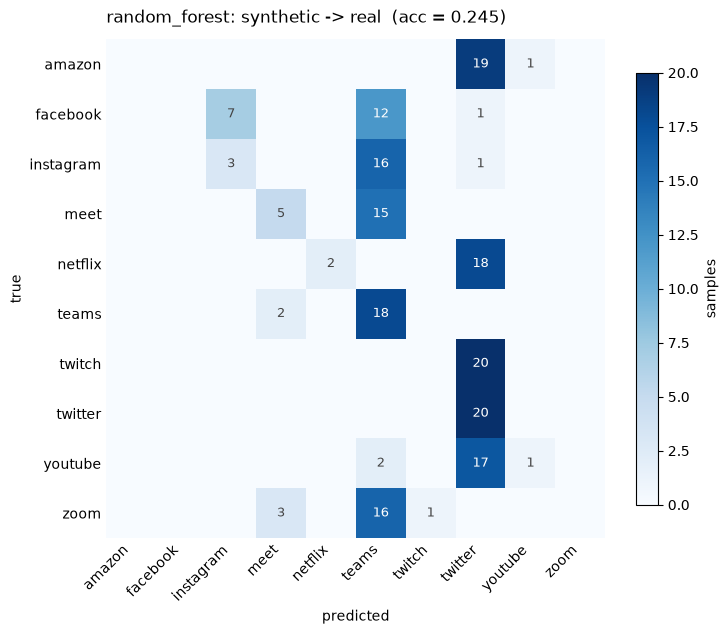


confusion matrix (rows = true, cols = predicted)
           amazon  facebook  instagram  meet  netflix  teams  twitch  twitter  youtube  zoom
amazon          0         0          0     0        0      0       0       19        1     0
facebook        0         0          7     0        0     12       0        1        0     0
instagram       0         0          3     0        0     16       0        1        0     0
meet            0         0          0     5        0     15       0        0        0     0
netflix         0         0          0     0        2      0       0       18        0     0
teams           0         0          0     2        0     18       0        0        0     0
twitch          0         0          0     0        0      0       0       20        0     0
twitter         0         0          0     0        0      0       0       20        0     0
youtube         0         0          0     0        0      2       0       17        1     0
zoom            0   

In [56]:
# 4
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.model_selection import StratifiedKFold, cross_val_score

X_test, y_test = TEST_DF[FEATURES].to_numpy(dtype=np.int16), TEST_DF["label"].to_numpy()
X_test = X_test[:, KEEP]          # same columns the models were trained on
print(f"test: {X_test.shape[0]} samples x {X_test.shape[1]} features\n")

preds = {name: m.predict(X_test) for name, m in models.items()}

# --- 4a. summary table -------------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
chance = DummyClassifier(strategy="stratified", random_state=0).fit(X_train, y_train)

rows = [{
    "model":            "chance baseline",
    "cross-domain acc": accuracy_score(y_test, chance.predict(X_test)),
    "macro-F1":         f1_score(y_test, chance.predict(X_test), average="macro"),
    "within-train CV":  np.nan,
}]
for name, m in models.items():
    rows.append({
        "model":            name,
        "cross-domain acc": accuracy_score(y_test, preds[name]),
        "macro-F1":         f1_score(y_test, preds[name], average="macro"),
        "within-train CV":  cross_val_score(m, X_train, y_train, cv=cv,
                                            scoring="accuracy").mean(),
    })

print(f"{DIRECTION}: {X_train.shape[0]} train -> {X_test.shape[0]} test, "
      f"{X_train.shape[1]} features, 10 balanced classes (chance = 0.100)\n")
print(pd.DataFrame(rows).set_index("model").round(3).to_string())

# --- 4b. per-class breakdown ------------------------------------------
best = max(preds, key=lambda k: accuracy_score(y_test, preds[k]))
print(f"\n--- per-class report: {best} ---")
print(classification_report(y_test, preds[best], zero_division=0))

# --- 4c. confusion matrix ---------------------------------------------
labels = sorted(set(y_test) | set(preds[best]))
cm = confusion_matrix(y_test, preds[best], labels=labels)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(cm, cmap="Blues", vmin=0)          # one hue, light -> dark

ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)), labels)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"{best}: {DIRECTION}  (acc = {accuracy_score(y_test, preds[best]):.3f})",
             loc="left", pad=12)

thresh = cm.max() / 2 if cm.max() else 1
for i in range(len(labels)):
    for j in range(len(labels)):
        if cm[i, j]:                               # zeros are noise in a 10x10 grid
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "#444", fontsize=9)

for s in ("top", "right", "left", "bottom"):
    ax.spines[s].set_visible(False)
ax.tick_params(length=0)
fig.colorbar(im, ax=ax, shrink=0.8, label="samples")
fig.tight_layout()
plt.show()

print("\nconfusion matrix (rows = true, cols = predicted)")
print(pd.DataFrame(cm, index=labels, columns=labels).to_string())

This assignment was completed with the assistance of AI.